# ForenSight Multimodal + AutoSplice — Google Colab Training Notebook

This notebook is for **ML training/evaluation in Google Colab**.

It does **not** run the final production frontend/backend. The intended workflow is:

**AutoSplice → manifest → validation → multimodal model training → test evaluation → `best.pt` → use `best.pt` in the FastAPI app backend.**

### Before you start
Put these in Google Drive:

1. `forensight_multimodal_full_code.zip`
2. Your downloaded/extracted AutoSplice dataset (or its archive)

For true multimodal training, you must correctly connect **image + caption + mask + label**.

## 1. Confirm GPU

In Colab, select a GPU runtime first. Then run this cell.

In [1]:
import torch, platform
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    raise RuntimeError("GPU is not enabled. Enable a GPU runtime before training.")

Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls -lah "/content/drive/MyDrive/ForenSight/"

total 461M
-rw------- 1 root root 461M Aug 28 05:52 AutoSplice-20260828T054956Z-1-001.zip
-rw------- 1 root root  48K Aug 26 18:14 forensight_multimodal_full_code.zip


## 3. Set your Drive paths

Edit these paths to match your Google Drive.

**Recommended:** keep the dataset in Drive for persistence, but copy/extract it to `/content` before training because reading thousands of small files directly from mounted Drive is slow.

In [4]:
from pathlib import Path

# EDIT THESE:
PROJECT_ZIP_DRIVE = Path("/content/drive/MyDrive/ForenSight/forensight_multimodal_full_code.zip")
AUTOSPLICE_DRIVE = Path("/content/drive/MyDrive/ForenSight/AutoSplice-20260828T054956Z-1-001.zip")

# Local Colab paths:
WORK_ROOT = Path("/content/forensight_work")
PROJECT_ROOT = WORK_ROOT / "forensight_multimodal"
AUTOSPLICE_LOCAL = Path("/content/AutoSplice")

WORK_ROOT.mkdir(parents=True, exist_ok=True)

print("Project ZIP exists:", PROJECT_ZIP_DRIVE.exists(), PROJECT_ZIP_DRIVE)
print("AutoSplice path exists:", AUTOSPLICE_DRIVE.exists(), AUTOSPLICE_DRIVE)

Project ZIP exists: True /content/drive/MyDrive/ForenSight/forensight_multimodal_full_code.zip
AutoSplice path exists: True /content/drive/MyDrive/ForenSight/AutoSplice-20260828T054956Z-1-001.zip


## 4. Copy and extract the ForenSight project locally

In [5]:
import shutil, zipfile, os

if not PROJECT_ZIP_DRIVE.exists():
    raise FileNotFoundError(PROJECT_ZIP_DRIVE)

local_zip = WORK_ROOT / "forensight_multimodal_full_code.zip"
shutil.copy2(PROJECT_ZIP_DRIVE, local_zip)

# Clean old extraction so reruns are reproducible
if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)

with zipfile.ZipFile(local_zip, "r") as z:
    z.extractall(WORK_ROOT)

print("Project root:", PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.exists())
print("Top-level files:", sorted(p.name for p in PROJECT_ROOT.iterdir())[:30])

Project root: /content/forensight_work/forensight_multimodal
Exists: True
Top-level files: ['.env.example', '.gitignore', 'Dockerfile', 'Makefile', 'README.md', 'app', 'artifacts', 'configs', 'data', 'docs', 'ml', 'pyproject.toml', 'requirements.txt', 'scripts', 'tests']


## 5. Copy AutoSplice to Colab local disk

This assumes `AUTOSPLICE_DRIVE` is an **extracted folder**.

If your Drive contains ZIP/RAR archives instead, extract those into `/content/AutoSplice` first and then continue.

In [6]:
import shutil, os, zipfile
from pathlib import Path

if not AUTOSPLICE_DRIVE.exists():
    raise FileNotFoundError(AUTOSPLICE_DRIVE)

if AUTOSPLICE_LOCAL.exists():
    print("Local AutoSplice already exists:", AUTOSPLICE_LOCAL)
else:
    print("Extracting dataset from Drive to local Colab disk...")
    # Ensure the target directory exists for extraction
    AUTOSPLICE_LOCAL.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(AUTOSPLICE_DRIVE, 'r') as zip_ref:
        zip_ref.extractall(AUTOSPLICE_LOCAL)
    print("Extraction complete.")

print("Local dataset:", AUTOSPLICE_LOCAL)

Extracting dataset from Drive to local Colab disk...
Extraction complete.
Local dataset: /content/AutoSplice


## 6. Install dependencies without replacing Colab's working CUDA PyTorch

In [7]:
%cd /content/forensight_work/forensight_multimodal

# Keep the Colab-provided torch/torchvision build, because it is already matched to the runtime CUDA.
!grep -vE '^(torch|torchvision)>=' requirements.txt > /tmp/forensight_colab_requirements.txt
!pip -q install -r /tmp/forensight_colab_requirements.txt

# Quick import check
import torch, timm, transformers, cv2, pandas, sklearn, yaml
print("torch:", torch.__version__)
print("timm:", timm.__version__)
print("transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

/content/forensight_work/forensight_multimodal
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.6/525.6 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 kB 17.5 MB/s eta 0:00:00
torch: 2.11.0+cu128
timm: 1.0.28
transformers: 5.15.1
CUDA: True Tesla T4


## 7. Inspect the real AutoSplice folder structure

Run this **before building the manifest**.

The public AutoSplice page confirms that the release includes authentic/manipulated images, manipulation masks, captions, and JPEG-100/90/75 variants, but the code should use the folders/files that actually exist in your download.

If you are unsure which paths are images, masks, and captions, copy this output and show it to ChatGPT before continuing.

In [8]:
from pathlib import Path
from collections import Counter

root = AUTOSPLICE_LOCAL

# Show directories up to a useful depth
dirs = []
for p in root.rglob("*"):
    if p.is_dir():
        rel = p.relative_to(root)
        if len(rel.parts) <= 3:
            dirs.append(str(rel))

print("DIRECTORIES (first 200):")
for d in sorted(dirs)[:200]:
    print(" ", d)

# Summarize file extensions
counter = Counter(p.suffix.lower() for p in root.rglob("*") if p.is_file())
print("\nFILE EXTENSIONS:")
print(counter)

# Candidate metadata/caption files
print("\nPOSSIBLE CAPTION/METADATA FILES:")
for p in root.rglob("*"):
    if p.is_file() and p.suffix.lower() in {".csv", ".json", ".jsonl", ".ndjson", ".txt"}:
        print(" ", p)

DIRECTORIES (first 200):
  AutoSplice

FILE EXTENSIONS:
Counter({'.zip': 1, '.pdf': 1, '.txt': 1})

POSSIBLE CAPTION/METADATA FILES:
  /content/AutoSplice/AutoSplice/README.txt


In [12]:
import json
from pathlib import Path
from pprint import pprint

BASE_DATA = Path(
    "/content/AutoSplice/extracted_data/AutoSplice"
)

CAPTION_DIR = BASE_DATA / "Caption"

json_files = sorted(CAPTION_DIR.glob("*.json"))

print("Total caption JSON files:", len(json_files))

for json_file in json_files[:3]:
    print("\n" + "=" * 80)
    print("FILE:", json_file.name)

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    print("Python type:", type(data))
    pprint(data)

Total caption JSON files: 1710

FILE: 39406.json
Python type: <class 'dict'>
{'id': 39406,
 'oriCaptionTerm': 'Ships',
 'ori_caption': 'Ships lie next to destroyed houses after being swept ashore '
                'at the height of Typhoon Haiyan in Tacloban',
 'userInputTerm': 'Buses'}

FILE: 39436.json
Python type: <class 'dict'>
{'id': 39436,
 'oriCaptionTerm': 'An auction sign',
 'ori_caption': 'An auction sign stands at the entrance Solyndra LLC building '
                'in Fremont California Solyndra filed for bankruptcy '
                'protection on Sept 6 days after shutting its operation and '
                'leaving 1100 workers jobless',
 'userInputTerm': 'A smoking-free sign'}

FILE: 39446.json
Python type: <class 'dict'>
{'id': 39446,
 'oriCaptionTerm': 'Tulsi Gabbard',
 'ori_caption': 'US Rep Tulsi Gabbard one of six Asian American Pacific '
                'Islanders who won new seats in Congress in November',
 'userInputTerm': 'A young girl'}


In [13]:
import json
import re
import pandas as pd
from pathlib import Path

BASE_DATA = Path(
    "/content/AutoSplice/extracted_data/AutoSplice"
)

CAPTION_DIR = BASE_DATA / "Caption"

OUTPUT_CSV = Path(
    "/content/forensight_work/forensight_multimodal/data/"
    "autosplice_caption_metadata.csv"
)

OUTPUT_CSV.parent.mkdir(
    parents=True,
    exist_ok=True
)


def make_edited_caption(
    original_caption,
    original_term,
    new_term
):
    """
    Replace the first occurrence of the original concept
    with the user-supplied replacement concept.
    """

    if not original_caption:
        return ""

    if not original_term or not new_term:
        return original_caption

    pattern = re.escape(
        str(original_term).strip()
    )

    edited, n = re.subn(
        pattern,
        str(new_term).strip(),
        str(original_caption),
        count=1,
        flags=re.IGNORECASE
    )

    # If exact text was not found, preserve the original
    # and flag it later for inspection.
    return edited


rows = []

json_files = sorted(
    CAPTION_DIR.glob("*.json")
)

for json_path in json_files:

    with open(
        json_path,
        "r",
        encoding="utf-8"
    ) as f:
        data = json.load(f)

    source_id = str(
        data.get("id", json_path.stem)
    )

    original_caption = str(
        data.get(
            "ori_caption",
            ""
        )
    ).strip()

    original_term = str(
        data.get(
            "oriCaptionTerm",
            ""
        )
    ).strip()

    replacement_term = str(
        data.get(
            "userInputTerm",
            ""
        )
    ).strip()

    manipulated_caption = make_edited_caption(
        original_caption,
        original_term,
        replacement_term
    )

    term_found = (
        original_term.lower()
        in original_caption.lower()
        if original_term
        else False
    )

    rows.append(
        {
            "source_id": source_id,

            "json_file": str(
                json_path
            ),

            "original_caption":
                original_caption,

            "original_term":
                original_term,

            "replacement_term":
                replacement_term,

            "manipulated_caption":
                manipulated_caption,

            "term_found":
                term_found
        }
    )


caption_df = pd.DataFrame(
    rows
)

caption_df.to_csv(
    OUTPUT_CSV,
    index=False
)

print(
    "Total JSON:",
    len(json_files)
)

print(
    "Rows written:",
    len(caption_df)
)

print(
    "Output:",
    OUTPUT_CSV
)

print(
    "Original caption coverage:",
    (
        caption_df[
            "original_caption"
        ].str.len() > 0
    ).mean()
)

print(
    "Replacement-term coverage:",
    (
        caption_df[
            "replacement_term"
        ].str.len() > 0
    ).mean()
)

print(
    "Original term found inside caption:",
    caption_df[
        "term_found"
    ].mean()
)

display(
    caption_df.head(10)
)

Total JSON: 1710
Rows written: 1710
Output: /content/forensight_work/forensight_multimodal/data/autosplice_caption_metadata.csv
Original caption coverage: 1.0
Replacement-term coverage: 1.0
Original term found inside caption: 1.0


,source_id,json_file,original_caption,original_term,replacement_term,manipulated_caption,term_found
0,39406,/content/AutoSplice/extracted_data/AutoSplice/...,Ships lie next to destroyed houses after being...,Ships,Buses,Buses lie next to destroyed houses after being...,True
1,39436,/content/AutoSplice/extracted_data/AutoSplice/...,An auction sign stands at the entrance Solyndr...,An auction sign,A smoking-free sign,A smoking-free sign stands at the entrance Sol...,True
2,39446,/content/AutoSplice/extracted_data/AutoSplice/...,US Rep Tulsi Gabbard one of six Asian American...,Tulsi Gabbard,A young girl,US Rep A young girl one of six Asian American ...,True
3,39457,/content/AutoSplice/extracted_data/AutoSplice/...,Manson on March 18 2009 at Corcoran State Pris...,Manson,An african man,An african man on March 18 2009 at Corcoran St...,True
4,39460,/content/AutoSplice/extracted_data/AutoSplice/...,Democratic presidential candidate Hillary Rodh...,Hillary Rodham Clinton,an African man,Democratic presidential candidate an African m...,True
5,39549,/content/AutoSplice/extracted_data/AutoSplice/...,The Holiday Lunch sandwich from Pret a Manger,Holiday Lunch sandwich,Apple Pie,The Apple Pie from Pret a Manger,True
6,39553,/content/AutoSplice/extracted_data/AutoSplice/...,Kittens play during the Kitty Halftime Show at...,Kittens,Dogs,Dogs play during the Kitty Halftime Show at Pu...,True
7,39576,/content/AutoSplice/extracted_data/AutoSplice/...,Thomas Jefferson,Thomas Jefferson,An African man,An African man,True
8,39578,/content/AutoSplice/extracted_data/AutoSplice/...,Former Florida Governor Jeb Bush said this wee...,Florida Governor Jeb Bush,African governor,Former African governor said this week that pe...,True
9,39579,/content/AutoSplice/extracted_data/AutoSplice/...,A police escort follows a convoy through the t...,truck,train,A police escort follows a convoy through the t...,True


In [14]:
from pathlib import Path

BASE_DATA = Path(
    "/content/AutoSplice/extracted_data/AutoSplice"
)

sample_ids = [
    "39406",
    "39436",
    "39446"
]

for sample_id in sample_ids:

    print(
        "\n" +
        "=" * 90
    )

    print(
        "SOURCE ID:",
        sample_id
    )

    print(
        "=" * 90
    )

    matches = []

    for p in BASE_DATA.rglob("*"):

        if (
            p.is_file()
            and sample_id
            in p.name
        ):
            matches.append(p)

    for p in sorted(matches):

        print(
            p.relative_to(
                BASE_DATA
            )
        )

    print(
        "Total:",
        len(matches)
    )


SOURCE ID: 39406
Authentic/39406.jpg
Caption/39406.json
Forged_JPEG100/39406_0.jpg
Forged_JPEG100/39406_1.jpg
Forged_JPEG100/39406_2.jpg
Forged_JPEG75/39406_0.jpg
Forged_JPEG75/39406_1.jpg
Forged_JPEG75/39406_2.jpg
Forged_JPEG90/39406_0.jpg
Forged_JPEG90/39406_1.jpg
Forged_JPEG90/39406_2.jpg
Mask/39406_mask.png
Total: 12

SOURCE ID: 39436
Authentic/39436.jpg
Caption/39436.json
Forged_JPEG100/39436_1.jpg
Forged_JPEG100/39436_2.jpg
Forged_JPEG75/39436_1.jpg
Forged_JPEG75/39436_2.jpg
Forged_JPEG90/39436_1.jpg
Forged_JPEG90/39436_2.jpg
Mask/39436_mask.png
Total: 9

SOURCE ID: 39446
Authentic/39446.jpg
Caption/39446.json
Forged_JPEG100/39446_0.jpg
Forged_JPEG100/39446_1.jpg
Forged_JPEG100/39446_2.jpg
Forged_JPEG75/39446_0.jpg
Forged_JPEG75/39446_1.jpg
Forged_JPEG75/39446_2.jpg
Forged_JPEG90/39446_0.jpg
Forged_JPEG90/39446_1.jpg
Forged_JPEG90/39446_2.jpg
Mask/39446_mask.png
Total: 12


In [15]:
from pathlib import Path
from collections import Counter

BASE_DATA = Path(
    "/content/AutoSplice/extracted_data/AutoSplice"
)

print(
    "AUTOSPLICE TOP LEVEL\n"
)

for p in sorted(
    BASE_DATA.iterdir()
):

    if p.is_dir():

        files = [
            x
            for x in p.rglob("*")
            if x.is_file()
        ]

        ext_counts = Counter(
            x.suffix.lower()
            for x in files
        )

        print(
            f"{p.name:25s}",
            f"{len(files):7d} files",
            dict(ext_counts)
        )

    else:

        print(
            p.name,
            "[FILE]"
        )

AUTOSPLICE TOP LEVEL

Authentic                    2273 files {'.jpg': 2273}
Caption                      1710 files {'.json': 1710}
Forged_JPEG100               3621 files {'.jpg': 3621}
Forged_JPEG75                3621 files {'.jpg': 3621}
Forged_JPEG90                3621 files {'.jpg': 3621}
Jia_AutoSplice_A_Text-Prompt_Manipulated_Image_Dataset_for_Media_Forensics_CVPRW_2023_paper.pdf [FILE]
Mask                         1710 files {'.png': 1710}
README.txt [FILE]


## 8. Set the exact image, mask, and caption paths

**You must edit this cell after inspecting Step 7.**

For true multimodal training, `CAPTIONS_FILE` should point to the actual caption/prompt metadata file.

Do not continue if you are guessing the mapping between images and masks/captions.

In [17]:
from pathlib import Path

# Dataset base path
DATASET_EXTRACT_PATH = AUTOSPLICE_LOCAL / "extracted_data"
BASE_DATA = DATASET_EXTRACT_PATH / "AutoSplice"

# Main dataset paths
IMAGES_ROOT = BASE_DATA
MASKS_ROOT = BASE_DATA / "Mask"
CAPTION_DIR = BASE_DATA / "Caption"

print("--- Verified Paths ---")

print(
    "IMAGES_ROOT:",
    IMAGES_ROOT,
    IMAGES_ROOT.exists()
)

print(
    "MASKS_ROOT:",
    MASKS_ROOT,
    MASKS_ROOT.exists()
)

print(
    "CAPTION_DIR:",
    CAPTION_DIR,
    CAPTION_DIR.exists()
)

# Find all caption JSON files
caption_jsons = sorted(
    CAPTION_DIR.glob("*.json")
)

print(
    "Total caption JSON files:",
    len(caption_jsons)
)

# Validation
missing = []

if not IMAGES_ROOT.exists():
    missing.append("IMAGES_ROOT")

if not MASKS_ROOT.exists():
    missing.append("MASKS_ROOT")

if not CAPTION_DIR.exists():
    missing.append("CAPTION_DIR")

if missing:
    raise RuntimeError(
        f"Missing: {', '.join(missing)}"
    )

if len(caption_jsons) == 0:
    raise RuntimeError(
        "Caption folder exists, but no JSON caption files were found."
    )

print("\n✅ Dataset paths verified successfully.")

--- Verified Paths ---
IMAGES_ROOT: /content/AutoSplice/extracted_data/AutoSplice True
MASKS_ROOT: /content/AutoSplice/extracted_data/AutoSplice/Mask True
CAPTION_DIR: /content/AutoSplice/extracted_data/AutoSplice/Caption True
Total caption JSON files: 1710

✅ Dataset paths verified successfully.


## 9. Build a leakage-aware manifest

The manifest links:

`image + mask + caption + class label + source_id + JPEG quality + split`

It also groups related source content so JPEG variants do not leak across train/validation/test.

If your caption metadata contains a true original/source image ID, add `--source-id-column YOUR_COLUMN`. That is preferable to filename heuristics.

In [19]:
import subprocess, sys
from pathlib import Path

CAPTIONS_FILE = OUTPUT_CSV

manifest = PROJECT_ROOT / "data" / "autosplice_manifest.csv"
manifest.parent.mkdir(exist_ok=True)

cmd = [
    sys.executable, "scripts/build_manifest.py",
    "--images-root", str(IMAGES_ROOT),
    "--masks-root", str(MASKS_ROOT),
    "--captions-file", str(CAPTIONS_FILE),
    "--output", str(manifest),
    "--train-ratio", "0.70",
    "--val-ratio", "0.15",
    "--seed", "42",
]

print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)

Running: /usr/bin/python3 scripts/build_manifest.py --images-root /content/AutoSplice/extracted_data/AutoSplice --masks-root /content/AutoSplice/extracted_data/AutoSplice/Mask --captions-file /content/forensight_work/forensight_multimodal/data/autosplice_caption_metadata.csv --output /content/forensight_work/forensight_multimodal/data/autosplice_manifest.csv --train-ratio 0.70 --val-ratio 0.15 --seed 42


CompletedProcess(args=['/usr/bin/python3', 'scripts/build_manifest.py', '--images-root', '/content/AutoSplice/extracted_data/AutoSplice', '--masks-root', '/content/AutoSplice/extracted_data/AutoSplice/Mask', '--captions-file', '/content/forensight_work/forensight_multimodal/data/autosplice_caption_metadata.csv', '--output', '/content/forensight_work/forensight_multimodal/data/autosplice_manifest.csv', '--train-ratio', '0.70', '--val-ratio', '0.15', '--seed', '42'], returncode=0)

## 10. Validate the manifest and dataset

In [20]:
!python scripts/validate_manifest.py --manifest data/autosplice_manifest.csv

Rows: 14846
Caption coverage: 0.00%
Split/label counts:
 split  label
test   0        1730
       1         506
train  0        8022
       1        2388
val    0        1674
       1         526
dtype: int64
Compression counts:
 split  compression_quality
test   75.0                    547
       90.0                    547
       100.0                   547
train  75.0                   2544
       90.0                   2544
       100.0                  2544
val    75.0                    530
       90.0                    530
       100.0                   530
dtype: int64
Warnings: 0
Errors: 0
Manifest validation passed.


In [21]:
# Deep validation opens every referenced image and mask.
# It may take a while, but run it before a long training session.
!python scripts/validate_manifest.py --manifest data/autosplice_manifest.csv --deep

Rows: 14846
Caption coverage: 0.00%
Split/label counts:
 split  label
test   0        1730
       1         506
train  0        8022
       1        2388
val    0        1674
       1         526
dtype: int64
Compression counts:
 split  compression_quality
test   75.0                    547
       90.0                    547
       100.0                   547
train  75.0                   2544
       90.0                   2544
       100.0                  2544
val    75.0                    530
       90.0                    530
       100.0                   530
dtype: int64
Warnings: 0
Errors: 0
Manifest validation passed.


## 11. Audit the manifest manually

This is especially important for multimodal work. We want:

- correct train/val/test separation,
- manipulated samples connected to the correct masks,
- high caption coverage,
- no `source_id` leakage.

In [22]:
import pandas as pd
from IPython.display import display

df = pd.read_csv("data/autosplice_manifest.csv")

print("Rows:", len(df))
print("\nSplit x label:")
display(df.groupby(["split", "label"]).size().rename("count").reset_index())

caption_ok = df["caption"].fillna("").astype(str).str.strip().ne("")
print("Caption coverage:", f"{caption_ok.mean()*100:.2f}%")

leak = df.groupby("source_id")["split"].nunique()
print("Source IDs appearing in >1 split:", int((leak > 1).sum()))

print("\nSample rows:")
display(df[["sample_id","source_id","image_path","mask_path","caption","label","compression_quality","split"]].head(10))

if caption_ok.mean() < 0.90:
    print("\nWARNING: Caption coverage is below 90%. Inspect your caption mapping before claiming true multimodal training.")
if (leak > 1).any():
    raise RuntimeError("SOURCE LEAKAGE DETECTED. Do not train until this is fixed.")

Rows: 14846

Split x label:


,split,label,count
0,test,0,1730
1,test,1,506
2,train,0,8022
3,train,1,2388
4,val,0,1674
5,val,1,526


Caption coverage: 0.00%
Source IDs appearing in >1 split: 0

Sample rows:


,sample_id,source_id,image_path,mask_path,caption,label,compression_quality,split
0,sample_000000,39406,/content/AutoSplice/extracted_data/AutoSplice/...,/content/AutoSplice/extracted_data/AutoSplice/...,NaN,1,NaN,test
1,sample_000001,39436,/content/AutoSplice/extracted_data/AutoSplice/...,/content/AutoSplice/extracted_data/AutoSplice/...,NaN,1,NaN,train
2,sample_000002,39446,/content/AutoSplice/extracted_data/AutoSplice/...,/content/AutoSplice/extracted_data/AutoSplice/...,NaN,1,NaN,train
3,sample_000003,39450,/content/AutoSplice/extracted_data/AutoSplice/...,NaN,NaN,0,NaN,val
4,sample_000004,39457,/content/AutoSplice/extracted_data/AutoSplice/...,/content/AutoSplice/extracted_data/AutoSplice/...,NaN,1,NaN,val
5,sample_000005,39460,/content/AutoSplice/extracted_data/AutoSplice/...,/content/AutoSplice/extracted_data/AutoSplice/...,NaN,1,NaN,train
6,sample_000006,39549,/content/AutoSplice/extracted_data/AutoSplice/...,/content/AutoSplice/extracted_data/AutoSplice/...,NaN,1,NaN,val
7,sample_000007,39553,/content/AutoSplice/extracted_data/AutoSplice/...,/content/AutoSplice/extracted_data/AutoSplice/...,NaN,1,NaN,train
8,sample_000008,39563,/content/AutoSplice/extracted_data/AutoSplice/...,NaN,NaN,0,NaN,test
9,sample_000009,39576,/content/AutoSplice/extracted_data/AutoSplice/...,/content/AutoSplice/extracted_data/AutoSplice/...,NaN,1,NaN,train


## 12. Configure a safe first Colab run

Start with `256 × 256`, batch size `4`, and a few epochs as a smoke run.

After the pipeline works, increase to `384` (or later `512`) and use the full epoch budget.

CLIP remains frozen by default to reduce GPU memory and overfitting.

In [23]:
from pathlib import Path
import yaml

config_path = Path("configs/default.yaml")
cfg = yaml.safe_load(config_path.read_text())

# First reliable Colab run:
cfg["data"]["manifest_path"] = "data/autosplice_manifest.csv"
cfg["data"]["image_size"] = 256
cfg["data"]["batch_size"] = 4
cfg["data"]["num_workers"] = 2

# Use 2 epochs for a smoke test. Change to 20 after the smoke test succeeds.
cfg["training"]["epochs"] = 2
cfg["training"]["patience"] = 2
cfg["training"]["amp"] = True

config_path.write_text(yaml.safe_dump(cfg, sort_keys=False))
print(config_path.read_text())

seed: 42
data:
  manifest_path: data/autosplice_manifest.csv
  image_size: 256
  batch_size: 4
  num_workers: 2
model:
  rgb_backbone: efficientnet_b0
  clip_model: openai/clip-vit-base-patch32
  pretrained_rgb: true
  freeze_clip: true
  forensic_channels: 64
  decoder_channels:
  - 256
  - 128
  - 64
  dropout: 0.3
training:
  epochs: 2
  lr: 0.0001
  weight_decay: 0.0001
  patience: 2
  amp: true
  grad_clip: 1.0
  class_pos_weight: null
loss:
  classification_weight: 0.4
  segmentation_bce_weight: 0.3
  segmentation_dice_weight: 0.3
inference:
  authentic_threshold: 0.35
  manipulated_threshold: 0.65
  mask_threshold: 0.5
  min_region_area_ratio: 0.001
  max_regions: 10



## 13. Smoke-test one batch and one forward pass

Do this before training for hours. It verifies that:

- the manifest can be loaded,
- image and mask shapes match,
- captions tokenize,
- EfficientNet loads,
- CLIP loads,
- GPU forward propagation works,
- classification and segmentation heads return valid tensors.

In [28]:
from pathlib import Path
import sys

# Path to the file to modify
file_path = Path("/content/forensight_work/forensight_multimodal/ml/models/multimodal.py")

# Read the original content
content = file_path.read_text()
lines = content.splitlines()

# Locate and patch the `image_feat = F.normalize(...)` line
for i, line in enumerate(lines):
    if line.strip() == "image_feat = F.normalize(image_feat, dim=-1)":
        lines.insert(i, "        if hasattr(image_feat, 'pooler_output'):")
        lines.insert(i + 1, "            image_feat = image_feat.pooler_output")
        break

# Locate and patch the `text_feat = F.normalize(...)` line
# Note: re-iterate through lines because previous insertions change indices
for i, line in enumerate(lines):
    if line.strip() == "text_feat = F.normalize(text_feat, dim=-1)":
        lines.insert(i, "        if hasattr(text_feat, 'pooler_output'):")
        lines.insert(i + 1, "            text_feat = text_feat.pooler_output")
        break

modified_content = "\n".join(lines)

# Write the modified content back
file_path.write_text(modified_content)

print(f"Patched {file_path.name} to handle BaseModelOutputWithPooling objects before F.normalize.")

# Reload the module to ensure the patch is applied for subsequent executions
if 'ml.models.multimodal' in sys.modules:
    del sys.modules['ml.models.multimodal']
print("ml.models.multimodal module reloaded.")

Patched multimodal.py to handle BaseModelOutputWithPooling objects before F.normalize.
ml.models.multimodal module reloaded.


In [29]:
import torch
from torch.utils.data import DataLoader
from transformers import CLIPProcessor
from ml.config import load_config
from ml.data import AutoSpliceDataset
from ml.models.multimodal import MultiModalForgeryNet

cfg = load_config("configs/default.yaml")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = CLIPProcessor.from_pretrained(cfg.model.clip_model)
ds = AutoSpliceDataset(
    cfg.data.manifest_path,
    split="train",
    processor=processor,
    image_size=cfg.data.image_size,
    training=True,
)
loader = DataLoader(ds, batch_size=1, shuffle=True, num_workers=0)
batch = next(iter(loader))

print("Image:", batch["image"].shape)
print("Raw image:", batch["image_raw"].shape)
print("Mask:", batch["mask"].shape)
print("CLIP pixels:", batch["clip_pixel_values"].shape)
print("Input IDs:", batch["input_ids"].shape)
print("Label:", batch["label"])
print("Caption present:", batch["caption_present"])
print("Caption:", batch["caption"][0][:200])

model = MultiModalForgeryNet(
    rgb_backbone=cfg.model.rgb_backbone,
    clip_model=cfg.model.clip_model,
    pretrained_rgb=cfg.model.pretrained_rgb,
    freeze_clip=cfg.model.freeze_clip,
    forensic_channels=cfg.model.forensic_channels,
    decoder_channels=tuple(cfg.model.decoder_channels),
    dropout=cfg.model.dropout,
).to(device).eval()

with torch.no_grad(), torch.autocast(device_type="cuda", enabled=device.type=="cuda"):
    out = model(
        image=batch["image"].to(device),
        image_raw=batch["image_raw"].to(device),
        clip_pixel_values=batch["clip_pixel_values"].to(device),
        input_ids=batch["input_ids"].to(device),
        attention_mask=batch["attention_mask"].to(device),
        caption_present=batch["caption_present"].to(device),
    )

print("Classification logit:", out["classification_logit"].shape)
print("Segmentation logits:", out["segmentation_logits"].shape)
print("CLIP similarity:", out["clip_similarity"].shape)
print("SMOKE TEST PASSED")

Image: torch.Size([1, 3, 256, 256])
Raw image: torch.Size([1, 3, 256, 256])
Mask: torch.Size([1, 1, 256, 256])
CLIP pixels: torch.Size([1, 3, 224, 224])
Input IDs: torch.Size([1, 77])
Label: tensor([0.])
Caption present: tensor([0.])
Caption: 


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Classification logit: torch.Size([1])
Segmentation logits: torch.Size([1, 1, 256, 256])
CLIP similarity: torch.Size([1])
SMOKE TEST PASSED


## 14. Train — smoke run first

With the current config this runs only 2 epochs.

If it succeeds, update `training.epochs` to 20 and optionally increase image size/batch size, then rerun this cell.

In [35]:
!rm -rf checkpoints_smoke
!PYTHONPATH=. python scripts/train.py --config configs/default.yaml --output-dir checkpoints_smoke

Device: cuda
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
Loading weights: 100% 398/398 [00:00<00:00, 15889.18it/s]
/content/forensight_work/forensight_multimodal/ml/train_engine.py:85: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.training.amp and device.type == "cuda")
{'epoch': 1, 'seconds': 475.42683577537537, 'train': {'loss': 0.43360121350638803, 'classification_loss': 0.3126450349681668, 'segmentation_bce': 0.16752047699202463, 'segmentation_dice_loss': 0.8609568073472418}, 'classification': {'accuracy': 0.9136363636363637, 'precision': 0.8346613545816733, 'recall': 0.7965779467680608, 'f1': 0.8151750972762646, 'roc_auc': 0.9663018838782362, 'threshold': 0.82

## 15. Switch to the real training configuration

A T4 may require a smaller batch depending on image size. Suggested progression:

- 256, batch 4–8
- 384, batch 2–4
- 512, batch 1–2

Use the largest stable setting that fits GPU memory. Do not choose resolution based only on speed; localization of small manipulated regions can be resolution-sensitive.

In [37]:
from pathlib import Path
import yaml

config_path = Path("configs/default.yaml")
cfg = yaml.safe_load(config_path.read_text())

cfg["data"]["image_size"] = 384
cfg["data"]["batch_size"] = 4
cfg["data"]["num_workers"] = 2

cfg["training"]["epochs"] = 20
cfg["training"]["patience"] = 5

config_path.write_text(yaml.safe_dump(cfg, sort_keys=False))
print(config_path.read_text())

seed: 42
data:
  manifest_path: data/autosplice_manifest.csv
  image_size: 384
  batch_size: 4
  num_workers: 2
model:
  rgb_backbone: efficientnet_b0
  clip_model: openai/clip-vit-base-patch32
  pretrained_rgb: true
  freeze_clip: true
  forensic_channels: 64
  decoder_channels:
  - 256
  - 128
  - 64
  dropout: 0.3
training:
  epochs: 20
  lr: 0.0001
  weight_decay: 0.0001
  patience: 5
  amp: true
  grad_clip: 1.0
  class_pos_weight: null
loss:
  classification_weight: 0.4
  segmentation_bce_weight: 0.3
  segmentation_dice_weight: 0.3
inference:
  authentic_threshold: 0.35
  manipulated_threshold: 0.65
  mask_threshold: 0.5
  min_region_area_ratio: 0.001
  max_regions: 10



## 16. Train the full multimodal model

In [36]:
!rm -rf checkpoints
!PYTHONPATH=. python scripts/train.py --config configs/default.yaml --output-dir checkpoints

Device: cuda
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
Loading weights: 100% 398/398 [00:00<00:00, 24231.51it/s]
/content/forensight_work/forensight_multimodal/ml/train_engine.py:85: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.training.amp and device.type == "cuda")
{'epoch': 1, 'seconds': 475.52437376976013, 'train': {'loss': 0.4331925716140199, 'classification_loss': 0.31150389779361337, 'segmentation_bce': 0.1675541809868286, 'segmentation_dice_loss': 0.8610824787193028}, 'classification': {'accuracy': 0.9090909090909091, 'precision': 0.8029739776951673, 'recall': 0.8212927756653993, 'f1': 0.8120300751879699, 'roc_auc': 0.9666846105273679, 'threshold': 0.775

## 17. Evaluate only once on the held-out test split

The checkpoint already contains the validation-calibrated classification and mask thresholds.

Do not tune thresholds on the test set.

In [39]:
!PYTHONPATH=. python scripts/evaluate.py     --checkpoint checkpoints/best.pt     --split test     --output evaluation.json

Loading weights: 100% 398/398 [00:00<00:00, 14455.98it/s]
{
  "classification": {
    "accuracy": 0.9141323792486583,
    "precision": 0.775438596491228,
    "recall": 0.8735177865612648,
    "f1": 0.8215613382899628,
    "roc_auc": 0.9663888825424387,
    "threshold": 0.5750000000000001
  },
  "localization": {
    "forged_dice": 0.8417282968839271,
    "forged_iou": 0.7910167853819434,
    "forged_pixel_precision": 0.8455483531111877,
    "forged_pixel_recall": 0.8999417158062579,
    "forged_pixel_accuracy": 0.9111744541842748,
    "authentic_pixel_accuracy": 0.9267148134872251,
    "mask_threshold": 0.2,
    "forged_samples": 506,
    "authentic_samples": 1730
  },
  "split": "test",
  "checkpoint": "/content/forensight_work/forensight_multimodal/checkpoints/best.pt"
}


## 18. Inspect evaluation metrics

In [40]:
import json, pprint

evaluation = json.load(open("evaluation.json"))
pprint.pp(evaluation)

{'classification': {'accuracy': 0.9141323792486583,
                    'precision': 0.775438596491228,
                    'recall': 0.8735177865612648,
                    'f1': 0.8215613382899628,
                    'roc_auc': 0.9663888825424387,
                    'threshold': 0.5750000000000001},
 'localization': {'forged_dice': 0.8417282968839271,
                  'forged_iou': 0.7910167853819434,
                  'forged_pixel_precision': 0.8455483531111877,
                  'forged_pixel_recall': 0.8999417158062579,
                  'forged_pixel_accuracy': 0.9111744541842748,
                  'authentic_pixel_accuracy': 0.9267148134872251,
                  'mask_threshold': 0.2,
                  'forged_samples': 506,
                  'authentic_samples': 1730},
 'split': 'test',
 'checkpoint': '/content/forensight_work/forensight_multimodal/checkpoints/best.pt'}


## 19. Plot training history for thesis analysis

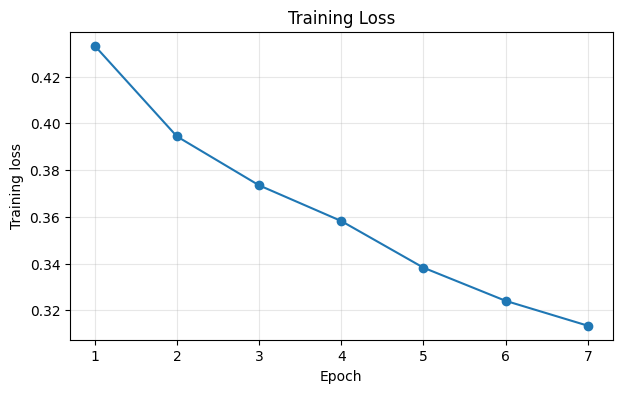

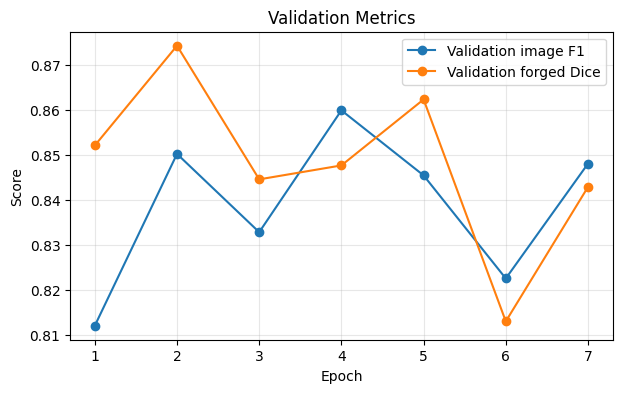

In [41]:
import json
import matplotlib.pyplot as plt

history = json.load(open("checkpoints/history.json"))

epochs = [r["epoch"] for r in history]
train_loss = [r["train"]["loss"] for r in history]
val_f1 = [r["classification"]["f1"] for r in history]
val_dice = [r["segmentation"].get("forged_dice", float("nan")) for r in history]

plt.figure(figsize=(7,4))
plt.plot(epochs, train_loss, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs, val_f1, marker="o", label="Validation image F1")
plt.plot(epochs, val_dice, marker="o", label="Validation forged Dice")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 20. Test real inference and create mask/overlay artifacts

This proves the trained checkpoint can be used by the future app backend.

In [45]:
import pandas as pd
import torch
from PIL import Image
from pathlib import Path

from ml.inference import ForgeryInferenceEngine, render_artifacts

# Define IMAGENET_MEAN and IMAGENET_STD directly or ensure they are imported
# These are standard ImageNet normalization constants
# Assuming these are missing from ml/inference.py and need to be added there
# For now, I will create a separate patch cell for this.

df = pd.read_csv("data/autosplice_manifest.csv")
row = df[df["split"].eq("test")].iloc[0]

image = Image.open(row["image_path"]).convert("RGB")
caption = "" if pd.isna(row.get("caption")) else str(row.get("caption", ""))

engine = ForgeryInferenceEngine("checkpoints/best.pt", torch.device("cuda"))
result = engine.predict(image, caption=caption)

print({k:v for k,v in result.items() if k != "mask_probability"})

preview_dir = Path("/content/forensight_preview")
render_artifacts(
    image,
    result["mask_probability"],
    preview_dir,
    threshold=result["mask_threshold"],
)
print("Artifacts:", list(preview_dir.iterdir()))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

NameError: name 'IMAGEN_STD' is not defined

In [46]:
from pathlib import Path
import sys

# Path to the file to modify
file_path = Path("/content/forensight_work/forensight_multimodal/ml/inference.py")

# Read the original content
content = file_path.read_text()
lines = content.splitlines()

# Define IMAGENET_MEAN and IMAGENET_STD
IMAGENET_MEAN = "[0.485, 0.456, 0.406]"
IMAGENET_STD = "[0.229, 0.224, 0.225]"

# Find the line after imports to insert the definitions
insert_index = 0
for i, line in enumerate(lines):
    if line.startswith("from") or line.startswith("import"):
        insert_index = i + 1
    elif not line.strip() and insert_index > 0:
        # Skip empty lines after imports, find the first non-empty line
        continue
    elif insert_index > 0: # Found first code line after imports
        break

# Insert the definitions
lines.insert(insert_index, "IMAGENET_STD = " + IMAGENET_STD)
lines.insert(insert_index, "IMAGENET_MEAN = " + IMAGENET_MEAN)

modified_content = "\n".join(lines)

# Write the modified content back
file_path.write_text(modified_content)

print(f"Patched {file_path.name} to include IMAGENET_MEAN and IMAGENET_STD.")

# Reload the module to ensure the patch is applied for subsequent executions
if 'ml.inference' in sys.modules:
    del sys.modules['ml.inference']
print("ml.inference module reloaded.")

Patched inference.py to include IMAGENET_MEAN and IMAGENET_STD.
ml.inference module reloaded.


## 21. Save the important outputs permanently to Google Drive

These are the files you need after the Colab runtime disappears.

For the app, the most important file is **`best.pt`**. The checkpoint already stores the model configuration and calibrated thresholds.

Also keep `evaluation.json`, `history.json`, the final config, and the manifest for reproducibility.

In [47]:
from pathlib import Path
import shutil, json

OUTPUT_DRIVE = Path("/content/drive/MyDrive/ForenSight/trained_model_v1")
OUTPUT_DRIVE.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    Path("checkpoints/best.pt"),
    Path("checkpoints/last.pt"),
    Path("checkpoints/history.json"),
    Path("evaluation.json"),
    Path("configs/default.yaml"),
    Path("data/autosplice_manifest.csv"),
]

for src in files_to_copy:
    if src.exists():
        dst = OUTPUT_DRIVE / src.name
        shutil.copy2(src, dst)
        print("Saved:", dst)

# Save the exact training source code with the model for reproducibility.
code_dst = OUTPUT_DRIVE / "forensight_multimodal_source.zip"
shutil.make_archive(
    str(code_dst.with_suffix("")),
    "zip",
    root_dir=str(PROJECT_ROOT.parent),
    base_dir=PROJECT_ROOT.name,
)
print("Saved source bundle:", code_dst)

Saved: /content/drive/MyDrive/ForenSight/trained_model_v1/best.pt
Saved: /content/drive/MyDrive/ForenSight/trained_model_v1/last.pt
Saved: /content/drive/MyDrive/ForenSight/trained_model_v1/history.json
Saved: /content/drive/MyDrive/ForenSight/trained_model_v1/evaluation.json
Saved: /content/drive/MyDrive/ForenSight/trained_model_v1/default.yaml
Saved: /content/drive/MyDrive/ForenSight/trained_model_v1/autosplice_manifest.csv
Saved source bundle: /content/drive/MyDrive/ForenSight/trained_model_v1/forensight_multimodal_source.zip


## 22. Create a compact deployment bundle for the app

The final app backend needs:

- `best.pt`
- the same `ml/` model/inference source code
- Python dependencies
- access to the CLIP model named inside the checkpoint (normally downloaded from Hugging Face at deployment time)

You do **not** need the training dataset inside the app.

In [48]:
from pathlib import Path
import shutil, os

bundle = Path("/content/deployment_bundle")
if bundle.exists():
    shutil.rmtree(bundle)

(bundle / "checkpoints").mkdir(parents=True)
shutil.copy2("checkpoints/best.pt", bundle / "checkpoints/best.pt")
shutil.copytree("ml", bundle / "ml")
shutil.copy2("requirements.txt", bundle / "requirements.txt")
shutil.copy2("evaluation.json", bundle / "evaluation.json")

archive = shutil.make_archive("/content/forensight_deployment_bundle", "zip", "/content/deployment_bundle")
drive_archive = OUTPUT_DRIVE / "forensight_deployment_bundle.zip"
shutil.copy2(archive, drive_archive)

print("Deployment bundle:", drive_archive)

Deployment bundle: /content/drive/MyDrive/ForenSight/trained_model_v1/forensight_deployment_bundle.zip


# After Colab: connect the trained model to the app

Copy `best.pt` into your backend, for example:

```text
backend/checkpoints/best.pt
```

Then configure the backend:

```text
CHECKPOINT_PATH=./checkpoints/best.pt
```

The FastAPI inference service loads the checkpoint and produces:

- manipulated/authentic probability,
- likely-authentic / inconclusive / likely-manipulated verdict,
- pixel manipulation probability map,
- binary mask,
- manipulated area,
- suspicious regions,
- image-text CLIP similarity (when text is supplied).

The **frontend never loads `best.pt` directly**. It sends the uploaded image/caption to the backend API, and the backend runs inference.

For reproducible thesis results, keep the exact manifest, config, source code, checkpoint, history, and `evaluation.json` together.